### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score

* We import all the necessary libraries before starting the project.

### Dataset Load

In [3]:
df=pd.read_csv(r"C:\Users\HP\Downloads\big_mart_sales (1).csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


* We load the Big Mart dataset from a CSV file into a DataFrame called df.
* df.head() displays the first 5 rows so we can see what the data looks like.

### Shape Check

In [5]:
print(df.shape)

(8523, 12)


* df.shape returns (rows, columns) — telling us how many records and features our dataset has.
* (8523, 12) means 8523 rows and 12 columns.

### Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


### df.info() gives us a summary of the dataset:
* Column names
* Data types (int, float, object)
* Count of non-null valuesThis helps us identify which columns have missing data and what types they are.

### Missing Values Check

In [9]:
df.isnull()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,False,False,False,False,False,False,False,False,False,False,False,False
8519,False,False,False,False,False,False,False,False,True,False,False,False
8520,False,False,False,False,False,False,False,False,False,False,False,False
8521,False,False,False,False,False,False,False,False,False,False,False,False


In [10]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

* df.isnull().sum() counts how many null (missing) values exist in each column.
* We found that Item_Weight and Outlet_Size had missing values — so we need to fix them.

### Statistical Summary

In [11]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


df.describe() gives statistical details for all numeric columns:
* count, mean, std, min, max, 25%, 50%, 75%
* This helps us understand the data distribution and spot outliers.

### Missing Value Treatment

In [18]:
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

In [19]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

 We fill missing values so our model doesn't break:
- Item_Weight is a numeric column → filled with mean (average value)
- Outlet_Size is a categorical column → filled with mode (most frequently occurring value)
- After filling, df.isnull().sum() should return 0 for both columns.

### Duplicate Check & Removal

In [4]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

- df.duplicated().sum() counts rows that are exact copies of other rows.
- drop_duplicates() removes them so we don't train our model on repeated data.

### Unique Values

In [5]:
for i in df.columns:
    print(i, df[i].nunique())

Item_Identifier 1559
Item_Weight 415
Item_Fat_Content 5
Item_Visibility 7880
Item_Type 16
Item_MRP 5938
Outlet_Identifier 10
Outlet_Establishment_Year 9
Outlet_Size 3
Outlet_Location_Type 3
Outlet_Type 4
Item_Outlet_Sales 3493


- For each column, we print how many unique values exist.
- This helps us understand categorical columns — for example, 
- Outlet_Type might have 4 unique values like Supermarket Type1, Type2, etc.

### Univariate Analysis

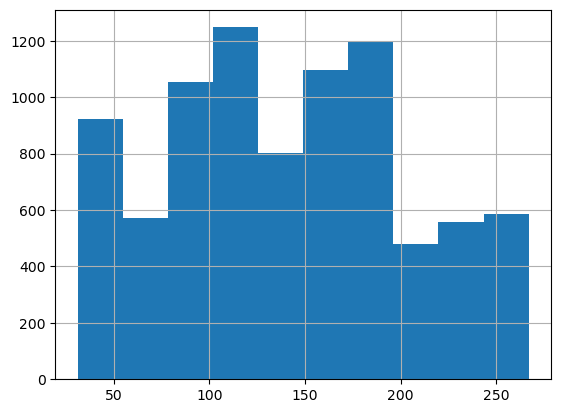

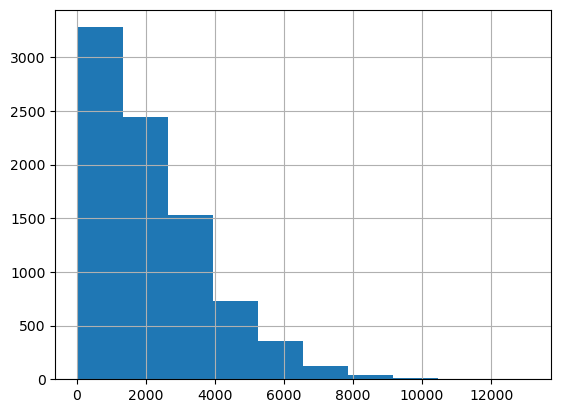

In [6]:
df["Item_MRP"].hist()
plt.show()

df["Item_Outlet_Sales"].hist()
plt.show()

We plot histograms for individual columns to understand their distribution:

- Item_MRP → shows how product prices are distributed
- Item_Outlet_Sales → shows how sales values are spread (our target variable)
- If the distribution is skewed, it may affect model performance.

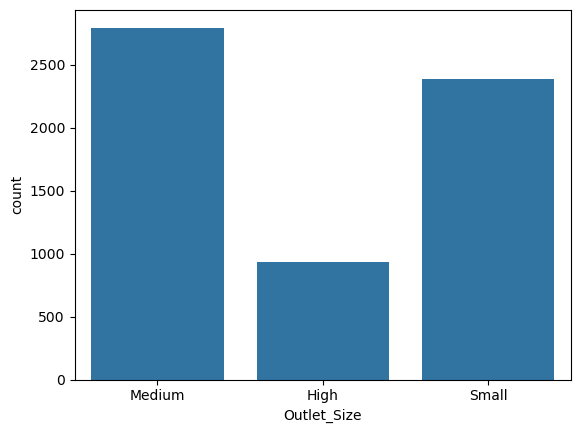

In [12]:
sns.countplot(x='Outlet_Size', data=df)
plt.show()

- A countplot shows how many outlets fall into each size category (Small, Medium, High).
- This tells us which outlet size is most common in the dataset.

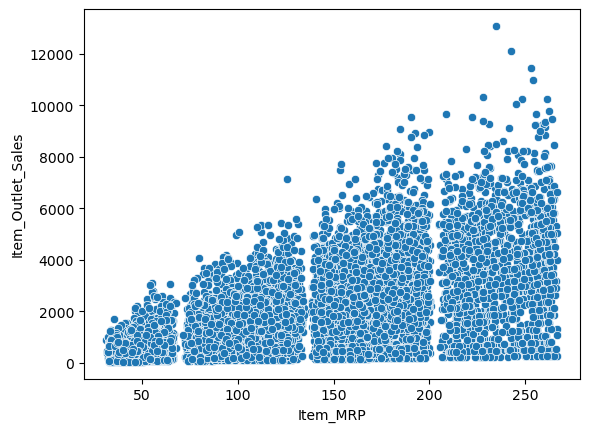

In [15]:
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df)
plt.show()

- We plot Item_MRP (price) vs Item_Outlet_Sales (sales) to check if there's a relationship.
- From the scatter plot, we can see a positive trend — higher priced items tend to generate more sales.


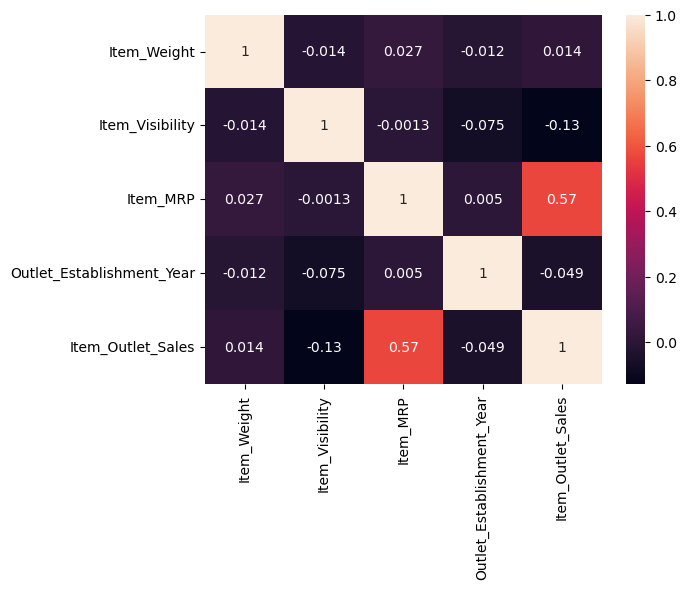

In [16]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.show()

A heatmap shows the correlation between all numeric columns.

- Values close to +1 → strong positive correlation
- Values close to -1 → strong negative correlation
- Values close to 0 → no relationship
- This helps us identify which features are most strongly related to sales.

### Feature Engineering

In [17]:
df['Outlet_Age'] = 2026 - df['Outlet_Establishment_Year']

- We create a new column Outlet_Age by subtracting the establishment year from the current year (2026).
- This is more meaningful for the model than the raw year — an outlet's age tells us how long it has been running.

### Label Encoding

In [18]:
le = LabelEncoder()
for i in df.select_dtypes(include='object'):
    df[i] = le.fit_transform(df[i].astype(str))

- Machine Learning models only work with numbers, not text.
- LabelEncoder converts categorical text columns into numeric values.
- For example: "Small" → 0, "Medium" → 1, "High" → 2
- We loop through all object-type columns and encode them automatically.

### Feature Selection

In [19]:
X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

We separate our data into:

- X → input features (everything except the target column)
- y → target variable (what we want to predict — Item_Outlet_Sales)

### Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

We split the data into training and testing sets:

- 80% Training → model learns from this
- 20% Testing → we evaluate how well the model performs on unseen data
- random_state=42 ensures the split is reproducible every time.

In [25]:
print(X_train.isnull().sum())

Item_Identifier                 0
Item_Weight                  1174
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type            0
Outlet_Type                     0
Outlet_Age                      0
dtype: int64


In [26]:
# Sab numeric columns ke NaN mean se bharo
X = X.fillna(X.mean())

# Phir split karo
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Phir model chalao
model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MAE: 855.6578247839905
MSE: 1303753.9803534308
R2 Score: 0.5203206994930893


In [27]:
print(X_train.isnull().sum())

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Outlet_Age                   0
dtype: int64


### Linear Regression Model

In [28]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

- We train a Linear Regression model — the simplest regression algorithm.
- It tries to find a straight-line relationship between the features and the target (sales).
- model.fit() trains the model using the training data.

### Prediction

In [29]:
pred = model.predict(X_test)

- After training, we use the model to predict sales on the test data (X_test).
- pred now contains the model's predicted sales values.

### Model Evaluation (Linear Regression)

In [30]:
print("MAE:", mean_absolute_error(y_test, pred))
print("MSE:", mean_squared_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MAE: 855.6578247839905
MSE: 1303753.9803534308
R2 Score: 0.5203206994930893


### Random Forest Model (Better Model)

In [31]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
pred2 = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, pred2))
print("MAE:", mean_absolute_error(y_test, pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred2)))

R2 Score: 0.5620840653389263
MAE: 757.9439396504399
RMSE: 1090.9823106280335


- Random Forest is an ensemble model — it builds many decision trees and averages their results.
- It is much more powerful than Linear Regression and handles non-linear relationships well.

- RMSE (Root Mean Squared Error) is added here — it's the square root of MSE, giving error in the same unit as sales.
- Random Forest almost always gives a higher R2 Score than Linear Regression on this dataset.